<a href="https://colab.research.google.com/github/Rmendivil94/retail-fraud-detection/blob/main/notebooks/01_EDA_and_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IEEE-CIS Fraud Detection: Exploratory Data Analysis**

In [18]:
# Loading the Kaggle token / Cargando el token de Kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"rodrigomendivil","key":"eb440019d11b04a83fccc0aa683fd856"}'}

In [19]:
# Downloading "ieee-fraud-detection" dataset / Descargando conjunto de datos "ieee-fraud-detection"
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c ieee-fraud-detection
!unzip ieee-fraud-detection.zip -d data/

ieee-fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ieee-fraud-detection.zip
replace data/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/sample_submission.csv  
replace data/test_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/test_identity.csv  
replace data/test_transaction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/test_transaction.csv  y

replace data/train_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: data/train_identity.csv  
replace data/train_transaction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: data/train_transaction.csv  


In [20]:
# Initial setup / Congfiguración inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Optimizing usage of RAM memory / Optimizando el uso de memoria RAM
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    if verbose:
        end_mem = df.memory_usage().sum() / 1024**2
        print('Memory usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

##**I. Preparing dataset | Preparando el conjunto de datos**


In [22]:
# 1. Load the data / Cargar los datos
print("Loading data... /Cargando datos...")
train_transaction = pd.read_csv('data/train_transaction.csv')
train_identity = pd.read_csv('data/train_identity.csv')

# 2. Merging with Left Join on Transaction ID / Unión con Left Join usando TransactionID
print("Merging tables / Fusionando tablas...")
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# 3. Reduce memory usage from original df's / Liberar memoria de los df originales
del train_transaction, train_identity
import gc
gc.collect()

# 4. Applying memory reduction function to the final df / Aplicar la reducción de memoria al df final
print("Optimizing memory... /Optimizando memoria...")
train = reduce_mem_usage(train)

# 5. Preview data / Vista inicial
train.head()

Loading data... /Cargando datos...
Merging tables / Fusionando tablas...
Optimizing memory... /Optimizando memoria...


/tmp/ipykernel_918/1233427909.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_918/1233427909.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_918/1233427909.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_918/1233427909.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_918/1233427909.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_918/1233427909.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_918/1233427909.py:20: RuntimeWarning:

Memory usage decreased to 645.97 Mb (67.0% reduction)


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


##**II. NULLS Analysis | Análisis de nulos**

###II.a) Counting nulls | Conteo de valores nulos

In [23]:
# 1. Nulls percentage per column / Calcular el porcentaje de nulos por columna
missing_percentages = (train.isnull().sum() / len(train)) * 100

# Columns with at least 1 null sorted descending / Columnas con al menos 1 nulo ordenadas de mayor a menor
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending = False)

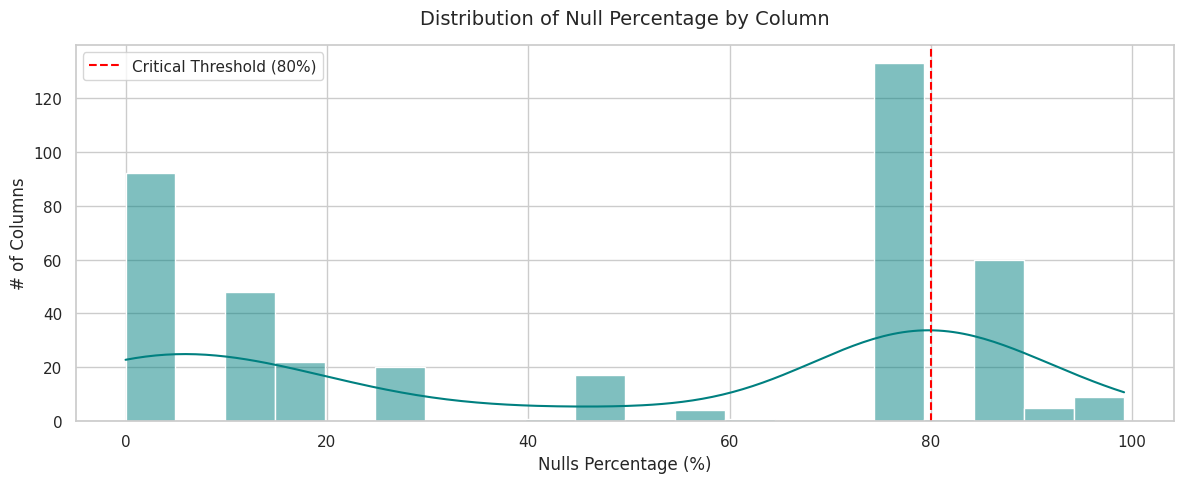

In [24]:
# 2. Visual setup / Configuración visual
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Graphic A: Null Distribution / Gráfico A: Distribución de nulos
plt.figure(figsize = (12, 5))
sns.histplot(missing_percentages, bins = 20, kde = True, color = 'teal')
plt.title('Distribution of Null Percentage by Column', fontsize = 14, pad = 15)
plt.xlabel('Nulls Percentage (%)', fontsize = 12)
plt.ylabel('# of Columns', fontsize = 12)
# Draw a red line at 80% as a threshold
plt.axvline(x = 80, color='red', linestyle = '--', label = 'Critical Threshold (80%)')
plt.legend()
plt.tight_layout()
plt.show()

#### EN: More than 120 columns exceed 70% missing values, so the threshold is set at 70%   


---


#### ES: Más de 120 columnas superan el 70% de valores perdidos, por lo que el umbral se fija en 70%

In [25]:
# Summary of Nulls | Resumen de nulos
print(f"Total columns with at least one missing value: {len(missing_percentages)}")
print(f"Columns with more than 70% of missing values: {sum(missing_percentages > 70)}")

Total columns with at least one missing value: 414
Columns with more than 70% of missing values: 208


###II.b) Drop > 70% null columns | Eliminar columnas > 70% vacías

#### EN: In transactional data, null values can also be part of fraudulent behavior, so the variable "nulls_count" is created before deleting columns with more than 70% null values, in order to keep information that the nulls could provide.


---


#### ES: En data transaccional, los valores nulos también pueden formar parte del comportamiento fraudulento, por lo que se crea la variable "nulls_count" antes de eliminar las columnas con más del 70% de valores nulos, esto con el fin de mantener la información que los nulos podrían aportar.

In [26]:
# 1. Counting nulls per row | Conteo de nulos por fila
train['nulls_count'] = train.isnull().sum(axis = 1)

# 2. Treshold | Umbral (70% = 0.70)
treshold = 0.70

# 3. Proportion of nulls that exceed the threshold | Proporción de nulos que superan el umbral
missing_ratios = train.isnull().mean()
columns_to_drop = missing_ratios[missing_ratios > treshold].index

# 4. Drop columns | Eliminar columnas
train = train.drop(columns = columns_to_drop)

# 5. Results | Resultados
print(f"Elimination treshold applied: > {treshold * 100}% of nulls")
print(f"Dropped columns: {len(columns_to_drop)}")
print(f"New shape of train dataset: {train.shape}")

/tmp/ipykernel_918/1199113191.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['nulls_count'] = train.isnull().sum(axis = 1)


Elimination treshold applied: > 70.0% of nulls
Dropped columns: 208
New shape of train dataset: (590540, 227)


In [27]:
train.head(10)

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V313,V314,V315,V316,V317,V318,V319,V320,V321,nulls_count
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,234
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,230
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,211
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,227
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,137
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,214
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,211
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,230
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,134
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,0.0,495.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,211


##**III. Target variable analysis | Análisis de variable objetivo**

###III.a) Counting and Percentages | Conteos y Porcentajes

In [28]:
# 1. Fraud count and Percentage | Conteo y porcentajes de fraude
fraud_counts = train['isFraud'].value_counts()
fraud_rates = train['isFraud'].value_counts(normalize = True) * 100

print("--- Target Variable Distribution (isFraud) ---")
print(f"Non Fraudulent Transactions (0): {fraud_counts[0]} ({fraud_rates[0]:.2f}%)")
print(f"Fraudulent Transactions (1): {fraud_counts[1]} ({fraud_rates[1]:.2f}%)")

--- Target Variable Distribution (isFraud) ---
Non Fraudulent Transactions (0): 569877 (96.50%)
Fraudulent Transactions (1): 20663 (3.50%)


/tmp/ipykernel_918/1651857423.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'isFraud', data = train, palette = ['green', 'red'])


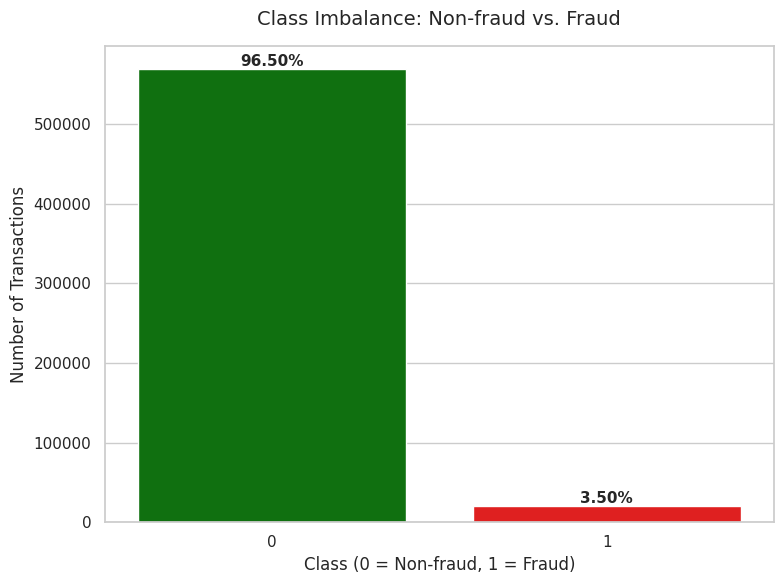

In [34]:
# 2. Chart Setting | Configuración de gráficos
plt.figure(figsize = (8 , 6))
sns.set_theme(style = "whitegrid")

# Barplot | Gráfico de barras
ax = sns.countplot(x = 'isFraud', data = train, palette = ['green', 'red'])
plt.title('Class Imbalance: Non-fraud vs. Fraud', fontsize = 14, pad = 15)
plt.xlabel('Class (0 = Non-fraud, 1 = Fraud)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# 3. Percentage label above the bars | Etiquetas de porcentaje encima de las barras
for p in ax.patches:
    height = p.get_height()
    total = len(train)
    ax.annotate(f'{height/total:.2%}',
                (p.get_x() + p.get_width() / 2., height),
                ha = 'center', va = 'bottom', fontsize = 11, fontweight = 'bold')

plt.tight_layout()
plt.show()

#### EN: Due to the severe class imbalance, Accuracy is a misleading metric and will not be considered; a naive model classifying all transactions as non-fraudulent would still achieve a 96.5% accuracy. Instead, ROC-AUC and particularly PR-AUC (Precision-Recall Area Under Curve) will be our primary evaluation metrics, as they effectively measure the model's true ability to separate signal from noise in highly imbalanced datasets. Optimizing for these metrics will allow us to strike the optimal balance between minimizing financial losses (false negatives) and preventing unnecessary friction for legitimate customers (false positives).


---


#### ES: Debido al evidente desbalanceo, el Accuracy del modelo no será una métrica a tomar en cuenta, dado que un modelo que clasifique todo como no fraude tendrá 96.5% de accuracy. Por otro lado, el ROC-AUC y especialmente el PR-AUC serán de máxima utilidad, ya que evalúan la capacidad real del modelo para separar la señal del ruido en escenarios desbalanceados. Optimizar estas métricas nos permitirá encontrar el equilibrio exacto entre minimizar el impacto financiero (falsos negativos) y evitar la fricción con clientes legítimos (falsos positivos).

###III.b) Financial behavior of fraud | Comportamiento financiero del fraude

In [30]:
# 1. TransactionAmt: Median & Mean | Mediana y Media
train['TransactionAmt'] = train['TransactionAmt'].astype('float32')
print("--- Summary of Transaction Amounts (USD) ---")
print("Non-fraud (0):")
print(train[train['isFraud'] == 0]['TransactionAmt'].describe()[['mean', '50%', 'max']])
print("\nFraud (1):")
print(train[train['isFraud'] == 1]['TransactionAmt'].describe()[['mean', '50%', 'max']])

--- Summary of Transaction Amounts (USD) ---
Non-fraud (0):
mean      134.511856
50%        68.500000
max     31936.000000
Name: TransactionAmt, dtype: float64

Fraud (1):
mean     149.244354
50%       75.000000
max     5192.000000
Name: TransactionAmt, dtype: float64


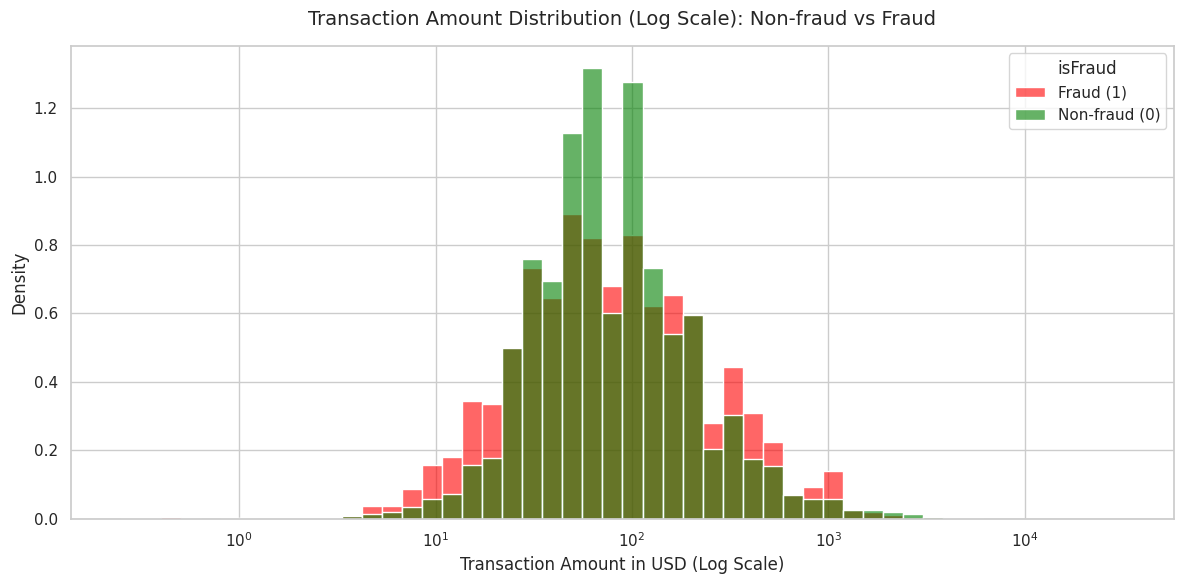

In [35]:
# 2. Visual settings | Configuración Visual
plt.figure(figsize = (12 , 6))
sns.set_theme(style = "whitegrid")

# 3. Logarithmic scale distribution chart | Gráfico de distribución con Escala Logarítmica
# We use log_scale=True because the amounts have a very long right tail (massive outliers)
# Usamos log_scale=True porque los montos tienen una cola derecha muy larga (outliers masivos)
ax = sns.histplot(
    data = train,
    x = 'TransactionAmt',
    hue = 'isFraud',
    common_norm = False,
    stat = 'density',
    log_scale = True,
    palette = ['green', 'red'],
    alpha = 0.6,
    bins = 50
)

plt.title('Transaction Amount Distribution (Log Scale): Non-fraud vs Fraud', fontsize = 14, pad = 15)
plt.xlabel('Transaction Amount in USD (Log Scale)', fontsize = 12)
plt.ylabel('Density', fontsize = 12)
plt.legend(title = 'isFraud', labels = ['Fraud (1)', 'Non-fraud (0)'])
plt.tight_layout()
plt.show()

#### EN: Both classes exhibit a right-skewed distribution with extreme outliers. However, the fraud behavior is highly calculated: the median and mid-tier amounts for fraudulent transactions are consistently higher than legitimate ones, indicating an effort to maximize the value extracted per compromised card. Conversely, the absolute maximum fraud amount (`$5,192`) is significantly lower than the legitimate maximum (`$31,936`). This strongly suggests that fraudsters deliberately avoid massive transaction amounts to bypass automated hard limits and manual review triggers set by the bank's risk rules.


---


#### ES: Ambas clases presentan una distribución sesgada a la derecha, con valores atípicos extremos (el 50% de las transacciones caen muy por debajo del promedio). Sin embargo, el comportamiento del fraude es distinto: la mediana y los tramos medios de transacciones fraudulentas son mayores que las legítimas, lo que indica un intento por maximizar la extracción de valor de cada tarjeta comprometida. A su vez, el monto máximo de fraude (`$5,192`) es considerablemente menor al máximo legítimo (`$31,936`), lo que sugiere que los estafadores evitan transacciones de montos masivos para no activar los umbrales de revisión manual y las reglas de bloqueo automatizado del banco.

###III.c) Time behavior of fraud | Comportamiento temporal del fraude



> Dado que el formato de la variable 'TransactionDT' es un número entero de segundos transcurridos desde cierto punto y no una fecha, creamos la función "decode_time_features()" para generar dos nuevas variables: 'day_of_week' y 'hours'





In [32]:
def decode_time_features(df):
    """
    Extract the hour of the day and the day of the week from TransactionDT (seconds).
    """
    # 1 hour = 3600 seconds. Divide and take the remainder of 24 hours.
    df['hour'] = (df['TransactionDT'] // 3600) % 24

    # 1 day = 86400 seconds. Divide and take the remainder of 7 days.
    df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7

    return df

# Apply the function to our df
train = decode_time_features(train)

print("New variables: 'hour' and 'day_of_week'")
print(train[['TransactionDT', 'hour', 'day_of_week', 'isFraud']].head())

Nuevas variables temporales creadas: 'hour' y 'day_of_week'
   TransactionDT  hour  day_of_week  isFraud
0          86400     0            1        0
1          86401     0            1        0
2          86469     0            1        0
3          86499     0            1        0
4          86506     0            1        0


/tmp/ipykernel_918/524826615.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour'] = (df['TransactionDT'] // 3600) % 24
/tmp/ipykernel_918/524826615.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7


/tmp/ipykernel_918/2842303839.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


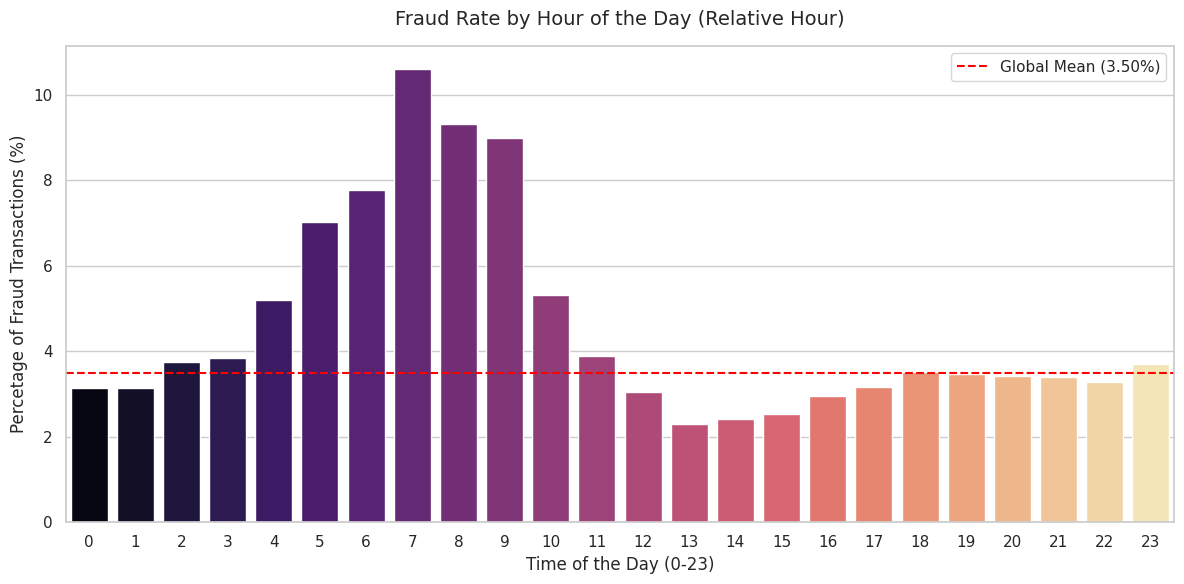

In [38]:
# Calculamos el porcentaje de fraude por cada hora
fraud_rate_by_hour = train.groupby('hour')['isFraud'].mean() * 100

# Configuración Visual
plt.figure(figsize = (12 , 6))
sns.set_theme(style = "whitegrid")

# Gráfico de barras de la tasa de fraude
ax = sns.barplot(
    x = fraud_rate_by_hour.index,
    y = fraud_rate_by_hour.values,
    palette = 'magma'
)

# Add a red line for the global percentage mean of fraud (aprox 3.5%)
global_fraud_rate = train['isFraud'].mean() * 100
plt.axhline(y = global_fraud_rate, color = 'red', linestyle = '--', label = f'Global Mean ({global_fraud_rate:.2f}%)')

plt.title('Fraud Rate by Hour of the Day (Relative Hour)', fontsize = 14, pad = 15)
plt.xlabel('Time of the Day (0-23)', fontsize = 12)
plt.ylabel('Percetage of Fraud Transactions (%)', fontsize = 12)
plt.legend()
plt.tight_layout()
plt.show()

#### EN: The fraud rate exhibits a severe spike between 4:00 AM and 10:00 AM (server time), with the probability of fraud exceeding 10% at the 7:00 AM mark. This pattern suggests two primary attack factors:
1.   The deliberate exploitation of off-peak hours when human fraud prevention teams have minimal staffing for manual reviews.
2.   Geographic arbitrage by international cybercrime syndicates operating from time zones where these hours correspond to their daytime business hours.
#### This highlights the critical need for stricter, fully automated ML thresholds during local non-working hours.


---
#### ES: La tasa de fraude presenta un pico severo entre las 4:00 a.m. y las 10:00 a.m. (hora local del servidor), alcanzando una probabilidad de fraude superior al 10% a las 7:00 a.m. Este patrón sugiere dos factores de ataque:

1.   La explotación intencional de ventanas de madrugada donde los equipos de prevención de fraude tienen menor dotación de personal para revisiones manuales.
2.   Arbitraje geográfico por parte de redes de cibercrimen internacionales, operando desde zonas horarias donde estas horas corresponden a su jornada laboral diurna.
####Esto remarca la necesidad de implementar umbrales de bloqueo automatizado más estrictos durante las horas on laborales locales.


##**IV. Save the clean Dataset | Guardar el dataset limpio**

In [40]:
# Save the clean dataset in Parquet format | Guardar el dataset limpio en formato Parquet
url_save = 'data/train_cleaned_eda.parquet'
train.to_parquet(url_save, index=False)

print(f"Clean data successfully saved in: {url_save}")

Clean data successfully saved in: data/train_cleaned_eda.parquet
